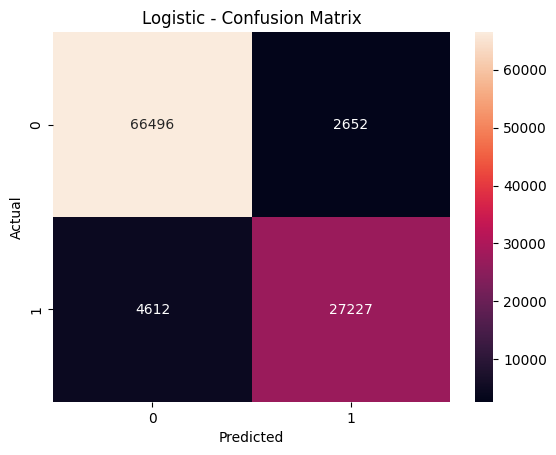

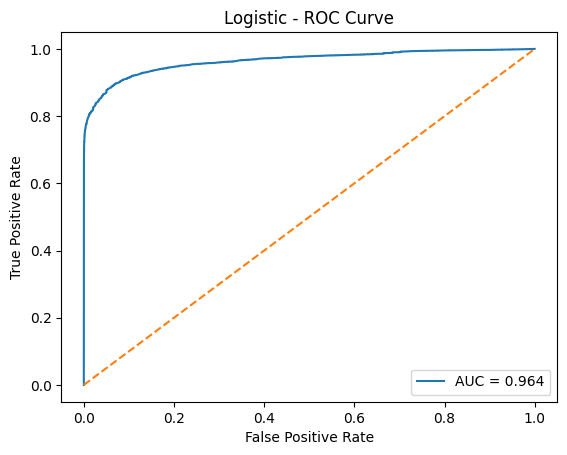

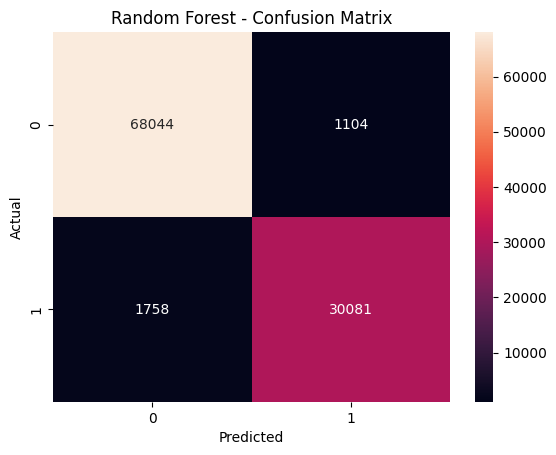

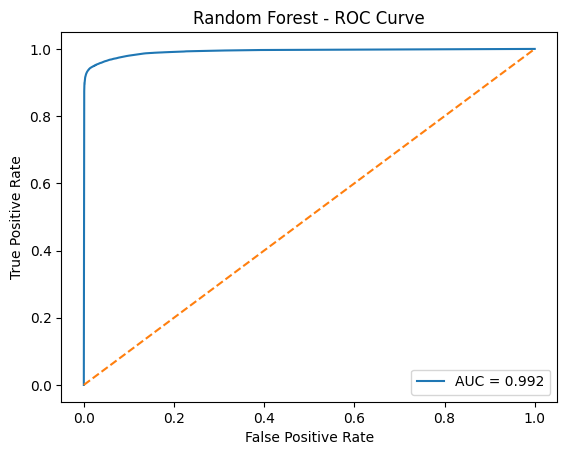

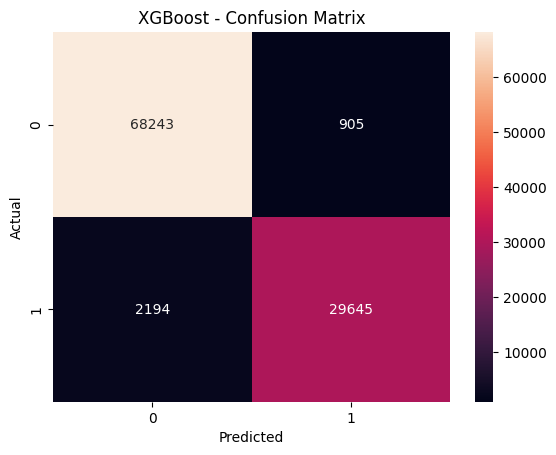

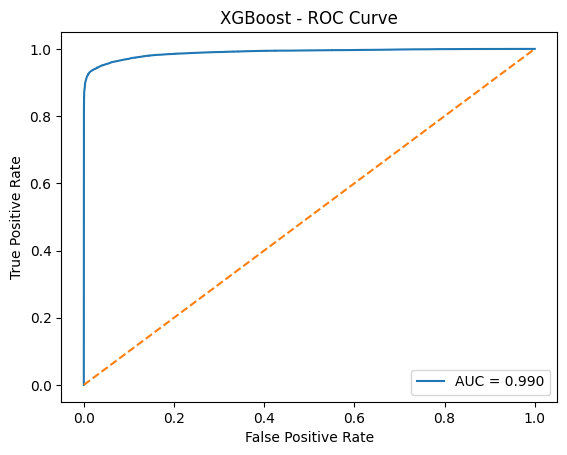

   Precision    Recall  F1-Score   ROC-AUC          Model
0   0.911242  0.855146  0.882303  0.964459       Logistic
1   0.964598  0.944785  0.954589  0.992349  Random Forest
2   0.970376  0.931091  0.950328  0.989706        XGBoost


In [1]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc

from src.preprocessing import balance_training_data
from src.models import (
    logistic_model,
    random_forest_model,
    xgboost_model
)
from src.evaluation import evaluate

# ==============================
# Load Data
# ==============================
X_train = pd.read_csv("../data/X_train_features.csv")
X_test = pd.read_csv("../data/X_test_features.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

X_train_bal, y_train_bal = balance_training_data(X_train, y_train)

# ==============================
# Train Models
# ==============================
models = {
    "Logistic": logistic_model(),
    "Random Forest": random_forest_model(),
    "XGBoost": xgboost_model()
}

results = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    metrics = evaluate(model, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)

    # Confusion Matrix
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

results_df = pd.DataFrame(results)
print(results_df)